In [1]:
import numpy as np

def expected_coincidences(alpha_deg, beta_deg, total_rate=1000):
    # Convert degrees to radians
    alpha = np.radians(alpha_deg)
    beta = np.radians(beta_deg)
    
    # Calculate probability for |psi+> = 1/sqrt(2) * (|HH> + |VV>)
    # P = |<alpha, beta|psi>|^2 = 1/2 * cos(alpha - beta)^2
    prob = 0.5 * (np.cos(alpha - beta)**2)
    
    return total_rate * prob

# Example usage
bases = [(0, 0), (0, 90), (45, 45), (90, 90)]
for a, b in bases:
    print(f"Basis ({a}, {b}): {expected_coincidences(a, b)} counts/s")

Basis (0, 0): 500.0 counts/s
Basis (0, 90): 1.874699728327322e-30 counts/s
Basis (45, 45): 500.0 counts/s
Basis (90, 90): 500.0 counts/s


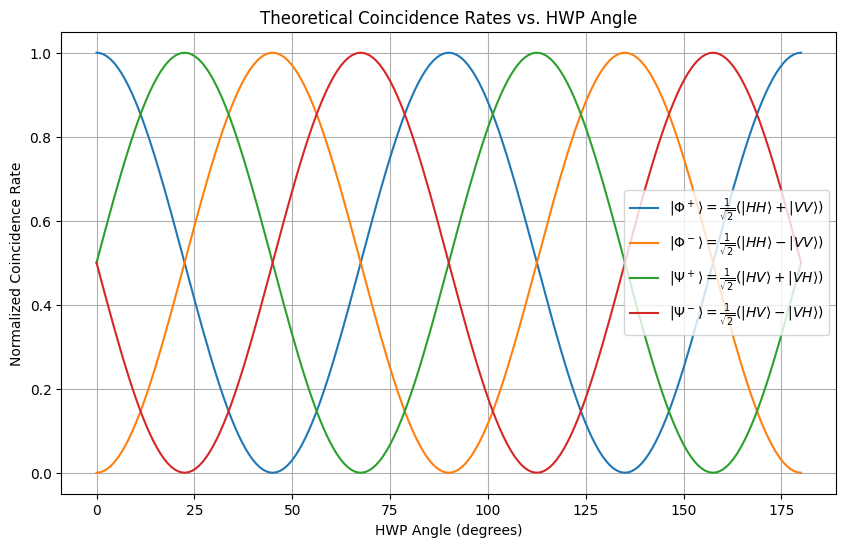

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define range of angles for HWP (0 to 180 degrees)
theta = np.linspace(0, 180, 200)
# Convert to radians for calculation
theta_rad = np.radians(theta)

# Theoretical coincidence rates for the 4 Bell states
# Assuming HWP rotates polarization by 2*theta, 
# and looking at correlation (e.g., HWP_A + HWP_B)
# These are simplified models of the 1+cos(4*theta) behavior
bell_phi_plus = 0.5 * (1 + np.cos(4 * theta_rad))
bell_phi_minus = 0.5 * (1 - np.cos(4 * theta_rad))
bell_psi_plus = 0.5 * (1 + np.cos(4 * theta_rad - np.pi/2))
bell_psi_minus = 0.5 * (1 - np.cos(4 * theta_rad - np.pi/2))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(theta, bell_phi_plus, label=r'$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|HH\rangle + |VV\rangle)$')
plt.plot(theta, bell_phi_minus, label=r'$|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|HH\rangle - |VV\rangle)$')
plt.plot(theta, bell_psi_plus, label=r'$|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|HV\rangle + |VH\rangle)$')
plt.plot(theta, bell_psi_minus, label=r'$|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|HV\rangle - |VH\rangle)$')

plt.title('Theoretical Coincidence Rates vs. HWP Angle')
plt.xlabel('HWP Angle (degrees)')
plt.ylabel('Normalized Coincidence Rate')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# validating bell purity
import pandas as pd

data = pd.read_csv('testing_bell_purity_2theta.csv')
data[['A', "B'", "AB'", "HWP A", "HWP B"]].head()

,A,B',AB',HWP A,HWP B
0,81868.2,70947.8,2816.32,-2.0,2.0
1,59123.0,38454.1,1482.46,43.0,47.0
2,17495.4,16959.8,746.63,88.0,92.0
3,82279.8,16970.3,54.34,-2.0,92.0


In [ ]:
import pandas as pd

data = pd.read_csv('final_snapshot_bell_state_purity.csv')
data[['A', "B'", "AB'", "HWP A", "HWP B"]].head()

,A,B',AB',HWP A,HWP B
0,82987.2,71808.2,2862.41,0.0,0.0
1,57062.9,41415.1,1481.57,45.0,45.0
2,17327.9,16973.6,762.36,90.0,90.0
3,83014.9,17049.7,27.15,0.0,90.0


In [43]:
2862 * np.cos(np.radians(45))**2, 2862 * np.cos(np.radians(90))**2

(1431.0000000000002, 1.073078124494559e-29)

In [51]:
phi = 90
2862 * 0.25 * ( 1 + np.cos(np.radians(phi)))

715.5

In [44]:
2862 / 2, 2862 / 4

(1431.0, 715.5)

Ideally? if sending 1000 counts

N | alpha | beta
--- | --- | ---
500 | 0 | 0
500 | 45 | 45
500 | 90 | 90
0 | 0 | 90

In [ ]:
import pandas as pd

# wrong i believe
data = pd.read_csv('testing_bell_purity_no_hwp_2theta.csv')
data[['A', "B'", "AB'", "HWP A", "HWP B"]].head()

,A,B',AB',HWP A,HWP B
0,82133.0,70970.2,2854.51,-2.0,2.0
1,18409.7,17464.9,713.78,43.0,47.0
2,81091.8,70576.3,2757.57,88.0,92.0
3,81959.2,70725.2,2801.73,-2.0,92.0


In [ ]:
import pandas as pd

data = pd.read_csv('final_alpha_beta_plots_data.csv')
coincidences = data[['A', "B'", "AB'", "HWP A", "HWP B"]]
coincidences

,A,B',AB',HWP A,HWP B
0,48633.5,67458.3,1507.79,-45.0,-22.5
1,48638.4,60670.8,737.79,-45.0,22.5
2,48636.2,17735.2,294.07,-45.0,67.5
3,48664.4,27652.1,971.94,-45.0,112.5
4,82448.6,27633.5,584.42,0.0,112.5
5,82437.0,17348.3,66.20,0.0,67.5
6,82545.2,60675.5,2329.82,0.0,22.5
7,82510.5,67633.1,2669.70,0.0,-22.5
8,54558.3,67494.4,1298.88,45.0,-22.5
9,54602.3,61141.7,1898.92,45.0,22.5


Fitted parameters for HWP A = -45: A=2650.18, alpha=-29.24, C=215.35
Fitted parameters for HWP A = 45: A=3787.00, alpha=12.03, C=40.87


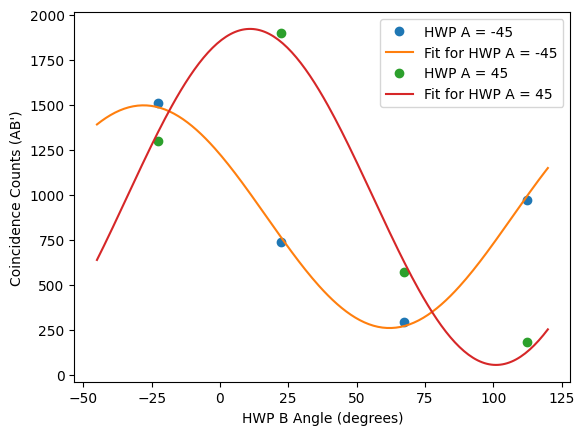

In [33]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

def model(beta, A, alpha, C):
	phi = 25  # Assuming phi = 0 for simplicity
	theta_l = 45

	alpha = np.radians(alpha) # I think used as an "offset" here
	beta = np.radians(beta)
	phi = np.radians(phi)
	theta_l = np.radians(theta_l)

	return A * (np.sin(alpha)**2 * np.sin(beta)**2 * np.cos(theta_l)**2 + 
                    np.cos(alpha)**2 * np.cos(beta)**2 * np.sin(theta_l)**2 + 
                    0.25 * np.sin(2*alpha) * np.sin(2*beta) * np.sin(2*theta_l) * np.cos(phi)) + C

# vals = [-45, 0, 45, 90]
vals = [-45, 45]
# vals = [0, 90]

for val in vals:
	cn = coincidences[coincidences['HWP A'] == val]
	plt.plot(cn['HWP B'], cn["AB'"], 'o', label=f'HWP A = {val}')

	popt, pcov = curve_fit(model, cn['HWP B'], cn["AB'"], p0=[1000, val, 0], bounds=([0, -180, 0], [1e5, 180, 1e5]))
	A, alpha, C = popt
	print(f'Fitted parameters for HWP A = {val}: A={A:.2f}, alpha={alpha:.2f}, C={C:.2f}')

	betas = np.linspace(-45, 120, 200)
	plt.plot(betas, model(betas, *popt), label=f'Fit for HWP A = {val}')



plt.xlabel("HWP B Angle (degrees)")
plt.ylabel("Coincidence Counts (AB')")
plt.legend()
plt.show()

In [34]:
import pandas as pd

paper = pd.read_csv("paper.csv")
paper

,alpha,beta,N_A,N_B,N,N_ac
0,-45,-22.5,84525,80356,842,10.0
1,-45,22.5,84607,82853,212,10.3
2,-45,67.5,83874,82179,302,10.1
3,-45,112.5,83769,77720,836,9.5
4,0,-22.5,87015,80948,891,10.3
5,0,22.5,86674,83187,869,10.6
6,0,67.5,87086,81846,173,10.5
7,0,112.5,86745,77700,261,9.9
8,45,-22.5,87782,80385,255,10.3
9,45,22.5,87932,83265,830,10.7


Fitted parameters for HWP A = 0: A=1883.09, alpha=-2.61, C=77.73
Fitted parameters for HWP A = 90: A=1987.82, alpha=85.21, C=64.05


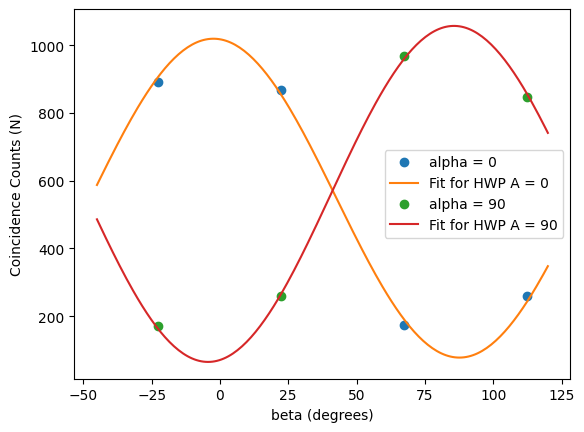

In [39]:
# vals = [-45, 0, 45, 90]
# vals = [-45, 45]
vals = [0, 90]

for val in vals:
	cn = paper[paper['alpha'] == val]
	plt.plot(cn['beta'], cn["N"], 'o', label=f'alpha = {val}')

	popt, pcov = curve_fit(model, cn['beta'], cn["N"], p0=[1000, val, 0], bounds=([0, -180, 0], [1e5, 180, 1e5]))
	A, alpha, C = popt
	print(f'Fitted parameters for HWP A = {val}: A={A:.2f}, alpha={alpha:.2f}, C={C:.2f}')

	betas = np.linspace(-45, 120, 200)
	plt.plot(betas, model(betas, *popt), label=f'Fit for HWP A = {val}')
	

plt.xlabel("beta (degrees)")
plt.ylabel("Coincidence Counts (N)")
plt.legend()
plt.show()

C:\Users\lexro\AppData\Local\Temp\ipykernel_5984\195998155.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Alpha: -45, Beta: -22.5
Alpha: -45, Beta: 22.5
Alpha: -45, Beta: 67.5
Alpha: -45, Beta: 112.5


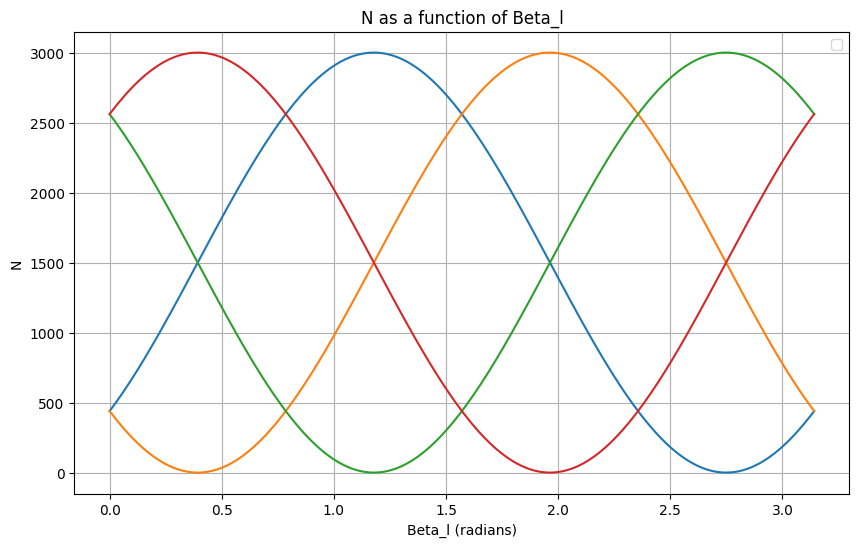

Alpha: 0, Beta: -22.5
Alpha: 0, Beta: 22.5
Alpha: 0, Beta: 67.5
Alpha: 0, Beta: 112.5


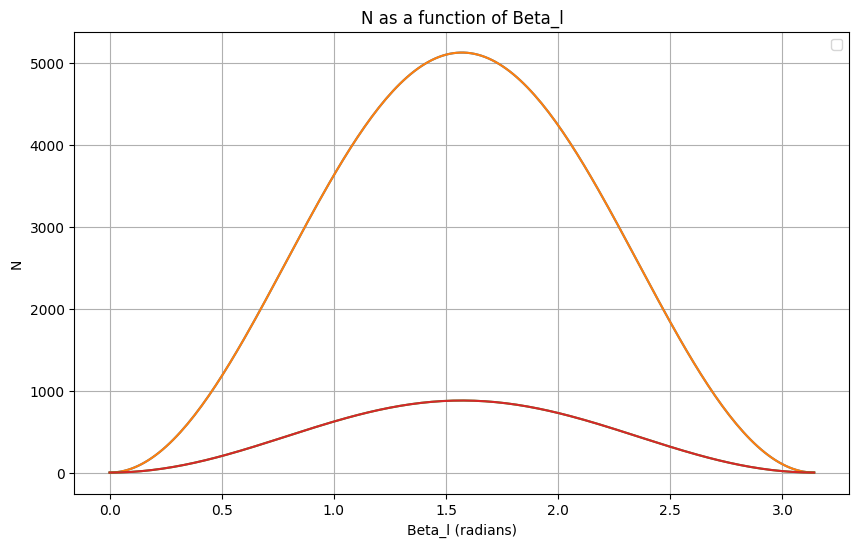

Alpha: 45, Beta: -22.5
Alpha: 45, Beta: 22.5
Alpha: 45, Beta: 67.5
Alpha: 45, Beta: 112.5


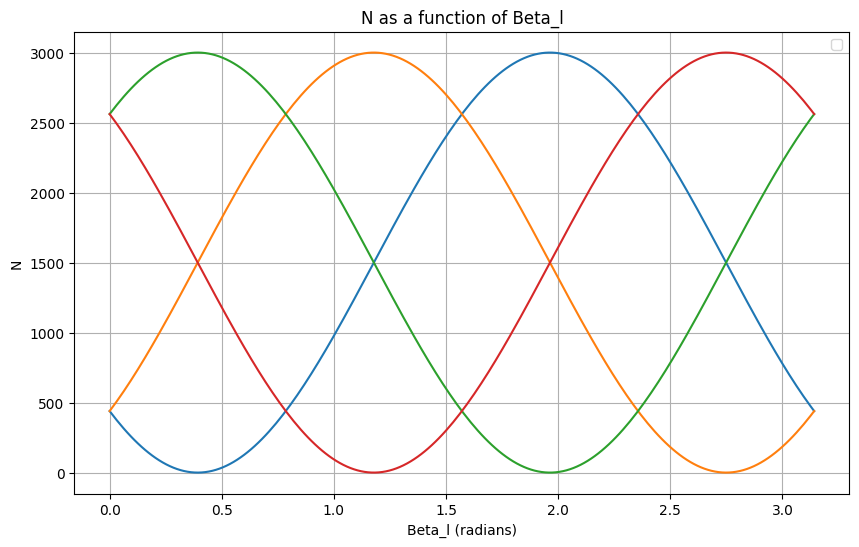

Alpha: 90, Beta: -22.5
Alpha: 90, Beta: 22.5
Alpha: 90, Beta: 67.5
Alpha: 90, Beta: 112.5


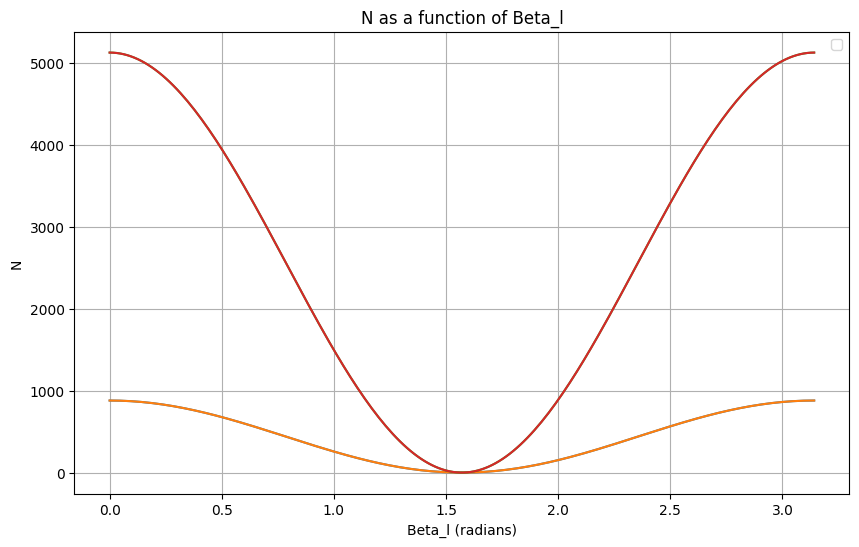

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



alphas = [-45, 0, 45, 90]
betas = [-22.5, 22.5, 67.5, 112.5]

for alpha in alphas:
        plt.figure(figsize=(10, 6))
        plt.title('N as a function of Beta_l')
        plt.xlabel('Beta_l (radians)')
        plt.ylabel('N')
        plt.grid()
        plt.legend()
        #plt.show()
        for beta in betas:
            A = 6000
            #N1 = A*(np.sin**2(alpha)*sin**2(beta)*cos**2(theta_l)+cos**2(alpha)*cos**2(beta)*sin**2(theta_l)+0.25*sin(2*alpha)*sin(2*beta)*sin(2*theta_l)*cos(phi))

            # Define range of angles for HWP (0 to 180 degrees) 
            theta_l = np.linspace(0, 180, 200)
            # Convert to radians for calculation
            theta_l_rad = np.radians(theta_l)
            # Example angles for alpha and beta
        
            alpha_rad = np.radians(alpha)
            beta_rad = np.radians(beta)
            # Calculate N for the given alpha, beta, and theta_l
            N = A * (np.sin(alpha_rad)**2 * np.sin(beta_rad)**2 * np.cos(theta_l_rad)**2 + 
                    np.cos(alpha_rad)**2 * np.cos(beta_rad)**2 * np.sin(theta_l_rad)**2 + 
                    0.25 * np.sin(2*alpha_rad) * np.sin(2*beta_rad) * np.sin(2*theta_l_rad) * np.cos(0))  # Assuming phi = 0
            # Plotting
            plt.plot(theta_l_rad, N, label='N vs Beta')
            print(f"Alpha: {alpha}, Beta: {beta}")

        plt.show()
        #plt.figure(figsize=(10, 6))
        #plt.plot(theta_l_rad, N, label='N vs Beta')
        '''
        plt.title('N as a function of Beta_l')
        plt.xlabel('Beta_l (degrees)')
        plt.ylabel('N')
        plt.grid()
        plt.legend()
        plt.show()
        print(f"Alpha: {alpha}, Beta: {beta}")
        '''


